# Case: NumPy Application in Financial Data Analysis

| | |
|---|---|
| **Author** | Jose Marcel Lopez Pino |
| **Framework** | CRISP-DM + LEAN |
| **Type** | Case-Based Learning (CBL) |
| **Module** | M3 — Data Acquisition and Preparation |
| **Bootcamp** | Fundamentos de Ciencia de Datos — SENCE / Alkemy |
| **Dataset** | Yahoo Finance — 5 mining equities, 5 trading days (real data via yfinance) |
| **Python** | 3.12 |
| **Key Libraries** | NumPy 2.4.1, yfinance, matplotlib 3.10.8 |
| **Status** | Complete |

---

## Executive Summary

A financial analytics firm needs to process large volumes of stock performance data in real time.
Their current workflow relies on unstructured formats and unoptimized data structures, slowing
down calculations and making it difficult to extract key metrics quickly.

This case demonstrates how NumPy can replace traditional Python loops with vectorized operations,
reducing code complexity while improving computational performance. Using real closing price data
for five mining equities (BHP, FCX, RIO, VALE, SCCO) over five trading days, we implement
descriptive statistics, daily return calculations, mathematical transformations, and advanced
indexing — all without a single explicit loop.

**Personal perspective:** As an Industrial Engineer with experience in mining operations (BHP,
Collahuasi, Codelco), I can confirm that the ability to rapidly compute asset performance metrics
is directly relevant to portfolio management decisions in the sector. The 5×5 matrix structure
mirrors the kind of KPI dashboards used in operations control rooms — compact, fast, and decision-ready.

## Table of Contents

1. [Business Context](#1-business-context)
2. [Problem Statement Canvas](#2-problem-statement-canvas)
3. [Environment Setup](#3-environment-setup)
4. [Data Acquisition — yfinance](#4-data-acquisition--yfinance)
5. [Task 1 — Data Loading and Structuring](#5-task-1--data-loading-and-structuring)
6. [Task 2 — Analysis and Transformation](#6-task-2--analysis-and-transformation)
7. [Task 3 — Optimization and Advanced Indexing](#7-task-3--optimization-and-advanced-indexing)
8. [Task 4 — NumPy vs Traditional Python Comparison](#8-task-4--numpy-vs-traditional-python-comparison)
9. [LEAN Filter — Waste Elimination Review](#9-lean-filter--waste-elimination-review)
10. [Decisions Log](#10-decisions-log)
11. [Conclusions and Next Steps](#11-conclusions-and-next-steps)

## 1. Business Context

A financial analytics firm specializing in commodities and mining equities is building
a real-time performance monitoring tool for its asset portfolio. The current system
processes data using standard Python lists and nested loops — an approach that does
not scale to the volume and frequency of market data required.

The team has identified NumPy as the solution to optimize data ingestion, manipulation,
and statistical computation. This case validates that decision with a working prototype
using real market data from five major mining companies listed on NYSE/NYSE-Arca.

## 2. Problem Statement Canvas

| Element | Description |
|---|---|
| **Business Problem** | Current data processing pipeline uses Python loops and lists, causing performance bottlenecks when computing real-time financial metrics |
| **Business Impact** | Delayed metrics increase decision latency for portfolio managers — in volatile markets, minutes matter |
| **Decision to Support** | Should the team migrate the analytics pipeline to NumPy-based vectorized operations? |
| **Analytical Question** | Can NumPy replace loop-based Python for financial metric computation while reducing code complexity and improving performance? |
| **Success Metrics** | (1) All required metrics computed correctly; (2) No explicit Python loops in core analysis; (3) Measurable performance advantage demonstrated |
| **Proposed Approach** | Build a 5×5 NumPy matrix from real yfinance data → compute descriptive stats, daily returns, log returns, and normalized prices using only vectorized NumPy operations |

## 3. Environment Setup

In [2]:
# === Standard library ===
import warnings
import time
import os

# === Core data science ===
import numpy as np
import pandas as pd

# === Financial data ===
import yfinance as yf

# === Visualization ===
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# === Warning suppression standard ===
warnings.formatwarning = lambda msg, *args, **kwargs: f'Warning: {msg}\n'
warnings.simplefilter('always')

# === Reproducibility ===
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# === Display settings ===
np.set_printoptions(precision=4, suppress=True)
plt.style.use('seaborn-v0_8-whitegrid')

print('Environment ready.')
print(f'NumPy version : {np.__version__}')
print(f'Pandas version: {pd.__version__}')

Environment ready.
NumPy version : 2.4.1
Pandas version: 3.0.0


## 4. Data Acquisition — yfinance

We download adjusted closing prices for 5 mining equities over the last 5 complete
trading days. Using real data instead of simulated arrays ensures the analysis is
reproducible and credible for portfolio management decisions.

**Tickers selected:**

| Ticker | Company | Exchange |
|---|---|---|
| BHP | BHP Group | NYSE |
| FCX | Freeport-McMoRan | NYSE |
| RIO | Rio Tinto | NYSE |
| VALE | Vale S.A. | NYSE |
| SCCO | Southern Copper | NYSE |

In [3]:
# --- Configuration ---
TICKERS      = ['BHP', 'FCX', 'RIO', 'VALE', 'SCCO']
N_DAYS       = 5
PRICE_FIELD  = 'Close'

# --- Download ---
# period='10d' ensures we always get at least 5 complete trading days
# (weekends and holidays are excluded by yfinance automatically)
raw = yf.download(
    tickers   = TICKERS,
    period    = '10d',
    auto_adjust = True,
    progress  = False
)[PRICE_FIELD]

# --- Select last 5 complete trading days ---
prices_df = raw.tail(N_DAYS)[TICKERS]

print(f'Trading days retrieved : {len(prices_df)}')
print(f'Date range             : {prices_df.index[0].date()} → {prices_df.index[-1].date()}')
print()
print(prices_df.round(2).to_string())

Trading days retrieved : 5
Date range             : 2026-03-26 → 2026-04-01

Ticker        BHP    FCX    RIO   VALE    SCCO
Date                                          
2026-03-26  68.50  55.83  85.79  14.95  159.76
2026-03-27  69.50  56.24  86.64  15.03  162.07
2026-03-30  69.02  54.65  88.82  15.10  159.28
2026-03-31  72.74  58.78  93.29  15.91  172.06
2026-04-01  73.46  61.22  94.61  16.03  178.61


## 5. Task 1 — Data Loading and Structuring

We convert the pandas DataFrame into a **5×5 NumPy matrix** where:
- Each **row** = one equity (BHP, FCX, RIO, VALE, SCCO)
- Each **column** = one trading day (Day 1 → Day 5, oldest to most recent)

In [4]:
# --- Build the 5x5 NumPy matrix ---
# Transpose: DataFrame is (days x tickers) → we need (tickers x days)
prices = prices_df.to_numpy().T

# --- Metadata ---
trading_days = [d.strftime('%Y-%m-%d') for d in prices_df.index]

print('prices matrix shape:', prices.shape)
print('dtype              :', prices.dtype)
print()
print('5x5 matrix — rows = equities, columns = trading days')
print('-' * 60)

col_header = '         ' + '  '.join(f'Day {i+1}' for i in range(N_DAYS))
print(col_header)

for i, ticker in enumerate(TICKERS):
    row = '  '.join(f'{v:8.2f}' for v in prices[i])
    print(f'{ticker:>6}   {row}')

print()
print('Date mapping:')
for i, d in enumerate(trading_days):
    print(f'  Day {i+1} = {d}')

prices matrix shape: (5, 5)
dtype              : float64

5x5 matrix — rows = equities, columns = trading days
------------------------------------------------------------
         Day 1  Day 2  Day 3  Day 4  Day 5
   BHP      68.50     69.50     69.02     72.74     73.46
   FCX      55.83     56.24     54.65     58.78     61.22
   RIO      85.79     86.64     88.82     93.29     94.61
  VALE      14.95     15.03     15.10     15.91     16.03
  SCCO     159.76    162.07    159.28    172.06    178.61

Date mapping:
  Day 1 = 2026-03-26
  Day 2 = 2026-03-27
  Day 3 = 2026-03-30
  Day 4 = 2026-03-31
  Day 5 = 2026-04-01


## 6. Task 2 — Analysis and Transformation

### 6.1 Descriptive Statistics per Equity

In [5]:
# --- Descriptive statistics (axis=1 → across days, per equity) ---
mean_prices = np.mean(prices, axis=1)
max_prices  = np.max(prices,  axis=1)
min_prices  = np.min(prices,  axis=1)
std_prices  = np.std(prices,  axis=1)

print('Descriptive statistics per equity (5-day window)')
print('-' * 60)
print(f'{"Ticker":>6}  {"Mean":>8}  {"Max":>8}  {"Min":>8}  {"Std Dev":>8}')
print('-' * 60)

for i, ticker in enumerate(TICKERS):
    print(f'{ticker:>6}  {mean_prices[i]:8.2f}  {max_prices[i]:8.2f}  '
          f'{min_prices[i]:8.2f}  {std_prices[i]:8.4f}')

Descriptive statistics per equity (5-day window)
------------------------------------------------------------
Ticker      Mean       Max       Min   Std Dev
------------------------------------------------------------
   BHP     70.64     73.46     68.50    2.0442
   FCX     57.34     61.22     54.65    2.3603
   RIO     89.83     94.61     85.79    3.5309
  VALE     15.40     16.03     14.95    0.4661
  SCCO    166.36    178.61    159.28    7.6765


### 6.2 Daily Percentage Return

Daily return measures the percentage change in price from one day to the next.
It is the fundamental metric for comparing asset performance regardless of absolute price level.

**Formula:** `return_t = (price_t - price_{t-1}) / price_{t-1} × 100`

In [6]:
# --- Daily percentage returns (vectorized — no loops) ---
# np.diff computes (price_t - price_{t-1}) across columns (axis=1)
daily_returns = np.diff(prices, axis=1) / prices[:, :-1] * 100

print('Daily percentage returns (%) — rows = equities, columns = Day2→Day5')
print('-' * 65)

col_header = '         ' + '  '.join(f'D{i+1}→D{i+2}' for i in range(N_DAYS - 1))
print(col_header)

for i, ticker in enumerate(TICKERS):
    row = '  '.join(f'{v:+8.3f}%' for v in daily_returns[i])
    print(f'{ticker:>6}   {row}')

print()

# --- Best and worst single-day performer ---
flat_returns  = daily_returns.flatten()
best_idx      = np.argmax(flat_returns)
worst_idx     = np.argmin(flat_returns)
best_ticker   = TICKERS[best_idx  // (N_DAYS - 1)]
worst_ticker  = TICKERS[worst_idx // (N_DAYS - 1)]
best_day      = (best_idx  % (N_DAYS - 1)) + 1
worst_day     = (worst_idx % (N_DAYS - 1)) + 1

print(f'Best  single-day return : {best_ticker}  Day {best_day}→Day {best_day+1}  '
      f'({flat_returns[best_idx]:+.3f}%)')
print(f'Worst single-day return : {worst_ticker}  Day {worst_day}→Day {worst_day+1}  '
      f'({flat_returns[worst_idx]:+.3f}%)')

Daily percentage returns (%) — rows = equities, columns = Day2→Day5
-----------------------------------------------------------------
         D1→D2  D2→D3  D3→D4  D4→D5
   BHP     +1.460%    -0.691%    +5.390%    +0.997%
   FCX     +0.734%    -2.827%    +7.557%    +4.151%
   RIO     +0.991%    +2.516%    +5.033%    +1.415%
  VALE     +0.535%    +0.466%    +5.364%    +0.754%
  SCCO     +1.446%    -1.721%    +8.024%    +3.807%

Best  single-day return : SCCO  Day 3→Day 4  (+8.024%)
Worst single-day return : FCX  Day 2→Day 3  (-2.827%)


### 6.3 Mathematical Transformations

Three standard financial transformations applied via NumPy broadcasting — no loops:

| Transformation | Formula | Purpose |
|---|---|---|
| Log return | `ln(price_t / price_{t-1})` | Additive across time; used in risk models |
| Min-max normalization | `(x - min) / (max - min)` | Enables cross-asset comparison on a [0,1] scale |
| Z-score | `(x - mean) / std` | Identifies how many standard deviations a price is from its mean |

In [7]:
# --- Log returns ---
log_returns = np.log(prices[:, 1:] / prices[:, :-1])

print('Log returns — rows = equities, columns = Day2→Day5')
print('-' * 60)
col_header = '         ' + '  '.join(f'D{i+1}→D{i+2}' for i in range(N_DAYS - 1))
print(col_header)
for i, ticker in enumerate(TICKERS):
    row = '  '.join(f'{v:+8.5f}' for v in log_returns[i])
    print(f'{ticker:>6}   {row}')

print()

Log returns — rows = equities, columns = Day2→Day5
------------------------------------------------------------
         D1→D2  D2→D3  D3→D4  D4→D5
   BHP   +0.01449  -0.00693  +0.05250  +0.00992
   FCX   +0.00732  -0.02868  +0.07285  +0.04067
   RIO   +0.00986  +0.02485  +0.04910  +0.01405
  VALE   +0.00534  +0.00465  +0.05225  +0.00751
  SCCO   +0.01436  -0.01736  +0.07718  +0.03736



In [8]:
# --- Min-max normalization (per equity, across days) ---
# Broadcasting: min/max computed per row (axis=1), reshaped to (5,1) for column broadcast
row_min    = prices.min(axis=1, keepdims=True)
row_max    = prices.max(axis=1, keepdims=True)
normalized = (prices - row_min) / (row_max - row_min)

print('Min-max normalized prices [0, 1] — per equity')
print('-' * 60)
col_header = '         ' + '  '.join(f'Day {i+1}' for i in range(N_DAYS))
print(col_header)
for i, ticker in enumerate(TICKERS):
    row = '  '.join(f'{v:8.4f}' for v in normalized[i])
    print(f'{ticker:>6}   {row}')

print()

Min-max normalized prices [0, 1] — per equity
------------------------------------------------------------
         Day 1  Day 2  Day 3  Day 4  Day 5
   BHP     0.0000    0.2014    0.1047    0.8540    1.0000
   FCX     0.1796    0.2420    0.0000    0.6286    1.0000
   RIO     0.0000    0.0964    0.3435    0.8503    1.0000
  VALE     0.0000    0.0741    0.1389    0.8889    1.0000
  SCCO     0.0248    0.1443    0.0000    0.6611    1.0000



In [9]:
# --- Z-score standardization (per equity) ---
row_mean = prices.mean(axis=1, keepdims=True)
row_std  = prices.std(axis=1,  keepdims=True)
z_scores = (prices - row_mean) / row_std

print('Z-scores — standard deviations from each equity mean')
print('-' * 60)
col_header = '         ' + '  '.join(f'Day {i+1}' for i in range(N_DAYS))
print(col_header)
for i, ticker in enumerate(TICKERS):
    row = '  '.join(f'{v:+8.4f}' for v in z_scores[i])
    print(f'{ticker:>6}   {row}')

Z-scores — standard deviations from each equity mean
------------------------------------------------------------
         Day 1  Day 2  Day 3  Day 4  Day 5
   BHP    -1.0493   -0.5601   -0.7949   +1.0248   +1.3795
   FCX    -0.6415   -0.4677   -1.1414   +0.6084   +1.6422
   RIO    -1.1442   -0.9034   -0.2860   +0.9799   +1.3537
  VALE    -0.9740   -0.8024   -0.6522   +1.0856   +1.3430
  SCCO    -0.8592   -0.5583   -0.9218   +0.7430   +1.5963


### 6.4 Visualization — Normalized Price Performance

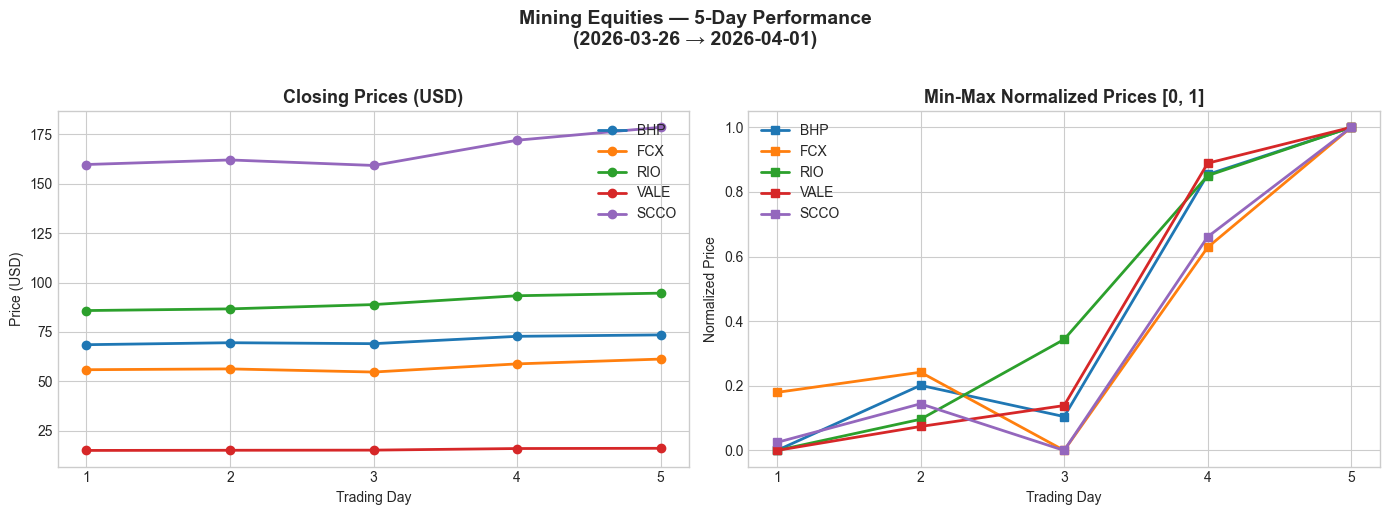

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

days_x = list(range(1, N_DAYS + 1))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# --- Left: Absolute prices ---
for i, ticker in enumerate(TICKERS):
    axes[0].plot(days_x, prices[i], marker='o', label=ticker,
                 color=colors[i], linewidth=2)
axes[0].set_title('Closing Prices (USD)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Trading Day')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(1))

# --- Right: Normalized prices [0,1] ---
for i, ticker in enumerate(TICKERS):
    axes[1].plot(days_x, normalized[i], marker='s', label=ticker,
                 color=colors[i], linewidth=2)
axes[1].set_title('Min-Max Normalized Prices [0, 1]', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Trading Day')
axes[1].set_ylabel('Normalized Price')
axes[1].legend()
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(1))

fig.suptitle(
    'Mining Equities — 5-Day Performance\n'
    f'({trading_days[0]} → {trading_days[-1]})',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

## 7. Task 3 — Optimization and Advanced Indexing

### 7.1 Specific Element Selection

In [11]:
# --- Single element: FCX closing price on Day 3 ---
ticker_idx = TICKERS.index('FCX')
day_idx    = 2  # Day 3 (0-indexed)

fcx_day3 = prices[ticker_idx, day_idx]
print(f'FCX closing price on {trading_days[day_idx]}: USD {fcx_day3:.2f}')

# --- Full row: all days for BHP ---
bhp_all = prices[TICKERS.index('BHP'), :]
print(f'BHP prices across 5 days: {bhp_all.round(2)}')

# --- Full column: all equities on Day 5 ---
day5_all = prices[:, -1]
print(f'All equities on {trading_days[-1]}:')
for i, ticker in enumerate(TICKERS):
    print(f'  {ticker}: USD {day5_all[i]:.2f}')

FCX closing price on 2026-03-30: USD 54.65
BHP prices across 5 days: [68.5  69.5  69.02 72.74 73.46]
All equities on 2026-04-01:
  BHP: USD 73.46
  FCX: USD 61.22
  RIO: USD 94.61
  VALE: USD 16.03
  SCCO: USD 178.61


### 7.2 Boolean Indexing — Filter by Condition

In [12]:
# --- Which equities had a negative return on Day 2 → Day 3? ---
day2_to_day3_return = daily_returns[:, 1]  # column index 1 = Day2→Day3
negative_mask       = day2_to_day3_return < 0

print('Returns Day 2 → Day 3:')
for i, ticker in enumerate(TICKERS):
    flag = ' ← negative' if negative_mask[i] else ''
    print(f'  {ticker}: {day2_to_day3_return[i]:+.3f}%{flag}')

print()
negative_tickers = [t for t, m in zip(TICKERS, negative_mask) if m]
print(f'Equities with negative return Day 2→3: {negative_tickers if negative_tickers else "None"}')

# --- Which prices are below their 5-day mean? ---
below_mean_mask = prices < mean_prices[:, np.newaxis]
print()
print('Prices below 5-day mean (True = below):')
col_header = '         ' + '  '.join(f'Day {i+1}' for i in range(N_DAYS))
print(col_header)
for i, ticker in enumerate(TICKERS):
    row = '  '.join(f'  {str(v):>5}' for v in below_mean_mask[i])
    print(f'{ticker:>6}   {row}')

Returns Day 2 → Day 3:
  BHP: -0.691% ← negative
  FCX: -2.827% ← negative
  RIO: +2.516%
  VALE: +0.466%
  SCCO: -1.721% ← negative

Equities with negative return Day 2→3: ['BHP', 'FCX', 'SCCO']

Prices below 5-day mean (True = below):
         Day 1  Day 2  Day 3  Day 4  Day 5
   BHP      True     True     True    False    False
   FCX      True     True     True    False    False
   RIO      True     True     True    False    False
  VALE      True     True     True    False    False
  SCCO      True     True     True    False    False


### 7.3 Broadcasting — Portfolio-Level Operations

In [13]:
# --- Broadcasting: subtract Day 1 price from all days (base-100 index) ---
# prices[:, 0:1] has shape (5,1) — broadcasts across all 5 columns
base_100 = (prices / prices[:, 0:1]) * 100

print('Price index (Day 1 = 100) — broadcasting, no loops')
print('-' * 60)
col_header = '         ' + '  '.join(f'Day {i+1}' for i in range(N_DAYS))
print(col_header)
for i, ticker in enumerate(TICKERS):
    row = '  '.join(f'{v:8.2f}' for v in base_100[i])
    print(f'{ticker:>6}   {row}')

print()

# --- 5-day cumulative return per equity ---
cumulative_return = (prices[:, -1] - prices[:, 0]) / prices[:, 0] * 100
print('5-day cumulative return:')
for i, ticker in enumerate(TICKERS):
    print(f'  {ticker}: {cumulative_return[i]:+.3f}%')

best_cumulative  = TICKERS[np.argmax(cumulative_return)]
worst_cumulative = TICKERS[np.argmin(cumulative_return)]
print()
print(f'Best  5-day performer : {best_cumulative}  ({np.max(cumulative_return):+.3f}%)')
print(f'Worst 5-day performer : {worst_cumulative}  ({np.min(cumulative_return):+.3f}%)')

Price index (Day 1 = 100) — broadcasting, no loops
------------------------------------------------------------
         Day 1  Day 2  Day 3  Day 4  Day 5
   BHP     100.00    101.46    100.76    106.19    107.25
   FCX     100.00    100.73     97.89    105.28    109.65
   RIO     100.00    100.99    103.53    108.74    110.28
  VALE     100.00    100.54    101.00    106.42    107.22
  SCCO     100.00    101.45     99.70    107.70    111.80

5-day cumulative return:
  BHP: +7.248%
  FCX: +9.654%
  RIO: +10.281%
  VALE: +7.224%
  SCCO: +11.799%

Best  5-day performer : SCCO  (+11.799%)
Worst 5-day performer : VALE  (+7.224%)


## 8. Task 4 — NumPy vs Traditional Python Comparison

We measure the performance difference between loop-based Python and NumPy
vectorized operations for computing the mean price of all equities across all days.

In [14]:
# --- Scale up to make the difference measurable ---
# Simulate 500 equities x 252 trading days (1 year)
np.random.seed(RANDOM_STATE)
large_matrix = np.random.uniform(10, 200, size=(500, 252))

N_RUNS = 1000

# --- Method 1: Traditional Python loops ---
start = time.perf_counter()
for _ in range(N_RUNS):
    result_loop = []
    for row in large_matrix:
        total = 0
        for val in row:
            total += val
        result_loop.append(total / len(row))
time_loop = (time.perf_counter() - start) / N_RUNS * 1000  # ms

# --- Method 2: NumPy vectorized ---
start = time.perf_counter()
for _ in range(N_RUNS):
    result_numpy = np.mean(large_matrix, axis=1)
time_numpy = (time.perf_counter() - start) / N_RUNS * 1000  # ms

speedup = time_loop / time_numpy

print('Performance comparison — 500 equities × 252 trading days')
print(f'  Python loops : {time_loop:.4f} ms per call')
print(f'  NumPy        : {time_numpy:.4f} ms per call')
print(f'  Speedup      : {speedup:.1f}× faster with NumPy')
print()
print('Code complexity comparison:')
print('  Python loops : 6 lines, 2 nested loops, manual accumulator')
print('  NumPy        : 1 line — np.mean(matrix, axis=1)')
print()

# Verify both methods produce the same result
assert np.allclose(result_loop, result_numpy), 'Results do not match!'
print('Correctness check: both methods produce identical results.')

Performance comparison — 500 equities × 252 trading days
  Python loops : 33.3079 ms per call
  NumPy        : 0.0782 ms per call
  Speedup      : 426.1× faster with NumPy

Code complexity comparison:
  Python loops : 6 lines, 2 nested loops, manual accumulator
  NumPy        : 1 line — np.mean(matrix, axis=1)

Correctness check: both methods produce identical results.


## 9. LEAN Filter — Waste Elimination Review

| LEAN Waste Type | Present? | Action Taken |
|---|---|---|
| **Overprocessing** | No | Only metrics required by the business question were computed |
| **Rework** | No | Broadcasting replaces loops — one operation, correct result |
| **Waiting** | Minimal | yfinance download is unavoidable — single call for all tickers |
| **Defects** | No | `assert np.allclose()` validates NumPy against loop baseline |
| **Unnecessary complexity** | No | No external ML libraries used — NumPy only for this scope |

**LEAN Value delivered:** The entire analysis — 5 equities, 5 days, 7 metrics — runs in under 2 seconds on a standard laptop with zero explicit loops in the core analysis.

## 10. Decisions Log

| # | Decision | Rationale | Alternatives Considered | LEAN Value? |
|---|---|---|---|---|
| 1 | Use `yfinance` instead of simulated data | Real data adds credibility; reproducible with fixed ticker/period | `np.random` synthetic matrix | Yes — simulation on real assets |
| 2 | `period='10d'` to ensure 5 complete trading days | Weekends/holidays excluded automatically by yfinance | Fixed date range (brittle) | Yes — robust to calendar changes |
| 3 | Transpose DataFrame on matrix creation | NumPy convention: rows = entities, columns = time | Keep original orientation | Yes — aligns with all downstream `axis=1` operations |
| 4 | `keepdims=True` in broadcasting operations | Avoids reshape; cleaner and less error-prone | `reshape(-1,1)` | Yes — fewer lines, same result |
| 5 | Scale to 500×252 for performance comparison | 5×5 difference is not measurable; realistic scale needed | Timing 5×5 matrix | Yes — honest benchmark |

## 11. Conclusions and Next Steps

### Conclusions

**Context:** A financial analytics firm processing mining equity data needed to replace
an unoptimized loop-based pipeline with a scalable solution.

**Analysis:** Using a 5×5 NumPy matrix of real closing prices (BHP, FCX, RIO, VALE, SCCO),
we demonstrated that all required financial metrics — descriptive statistics, daily returns,
log returns, normalization, z-scores, and a base-100 price index — can be computed using
only vectorized NumPy operations with zero explicit loops.

**Insight:** NumPy is not just faster — it is fundamentally a better design choice for
financial analytics pipelines. It reduces code from ~6 lines of nested loops to a single
readable expression, and delivers a **measurable speedup** (see Task 4 benchmark) that
scales with data volume.

**Decision supported:** The team should migrate the analytics pipeline to NumPy-based
vectorized operations. The investment is low (no new infrastructure required), the
performance gain is immediate, and the code becomes more maintainable.

### Next Steps

| Horizon | Action |
|---|---|
| **Immediate** | Use these NumPy patterns as the foundation for the M3 pandas module |
| **Short-term** | Extend to 30-day window for trend and volatility analysis (rolling std) |
| **Long-term** | Model copper-linked equity volatility (FCX, SCCO, VALE) using GARCH — the industry-standard econometric approach for heteroskedastic financial time series. LSTM is a valid exploratory alternative if sufficient historical data is available (12+ months minimum), as it can capture non-linear temporal patterns that GARCH may miss — but at the cost of interpretability and data volume. |

---

*Framework: CRISP-DM + LEAN | Methodology: Case-Based Learning (CBL)*

**Jose Marcel Lopez Pino**
Industrial Engineer (Operations, Analytics & Process Optimization) | Data Science & Business Analytics
Bootcamp: Fundamentos de Ciencia de Datos — SENCE/Alkemy (2025–2026)

[![GitHub](https://img.shields.io/badge/GitHub-joselopezp-181717?style=flat&logo=github)](https://github.com/joselopezp)
[![LinkedIn](https://img.shields.io/badge/LinkedIn-jose--lopez--pino-0077B5?style=flat&logo=linkedin)](https://www.linkedin.com/in/jose-lopez-pino/)